## Tarea 2: Tuning of SVM and MLP

a)  Disponer en colab el dataset Loan Data. Identificar como clase el atributo ‘not.fully.paid’.
Transformar el atributo purpose en un conjunto de variables binarias, usando get dummies() con la opción drop first=True.
Separar los datos en un conjunto de entrenamiento, reservando el 33 % para testing, usando random state=42 y stratify=y. Estandarizar los datos usando StandardScaler.

In [19]:
# Librerías estándar
import warnings
from pathlib import Path

# Manejo de datos y gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocesamiento y selección de modelos
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier

# Advertencias de sklearn
from sklearn.exceptions import ConvergenceWarning

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    balanced_accuracy_score,
)

In [20]:
# Ruta al dataset, relativa a la carpeta del notebook
DATA_PATH = Path("loan_data.csv")

df = pd.read_csv(DATA_PATH)

# Nombres de las clases de 'not.fully.paid' para las matrices de confusión
CLASS_LABELS = ['Paga (0)', 'No paga (1)']
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


### Atributos categóricos

Se observa que el atributo 'purpose' es de tipo 'object'. Dado que queremos que todos los atributos sean numéricos, la estrategia consiste en separar esta columna y agregar 7 columnas adicionales, una para cada propósito, utilizando get_dummies para binarizar los valores de la columna 'purpose'.

En este caso, las categorías no tienen un orden explícito, por lo que no es posible aplicar un ordinal encoding.

In [21]:
df_num = pd.get_dummies(df, columns=['purpose'], drop_first = True)
df_num.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


In [22]:
X = df_num.drop('not.fully.paid', axis=1)
y = df_num['not.fully.paid']

test_fraction = 0.33

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_fraction, stratify=y, random_state=42)

print(len(X_train),len(X_test))


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

6417 3161


### Separación en train y test estratificada

Al usar `stratify=y`, `train_test_split` separa cada clase por separado, de modo que el conjunto de entrenamiento y el de testing conservan la misma proporción de clases que el dataset completo. Sin esta opción la partición es completamente aleatoria y, con clases desbalanceadas, la proporción de la clase minoritaria podría variar bastante entre train y test.

| Conjunto | Ejemplos | Clase 0 (paga) | Clase 1 (no paga) | % clase 1 |
|---|---|---|---|---|
| Total | 9578 | 8045 | 1533 | 16,0 % |
| Train | 6417 | 5390 | 1027 | 16,0 % |
| Test | 3161 | 2655 | 506 | 16,0 % |

Esto es importante porque:

- **El test es representativo:** refleja la proporción real de deudores (16 %) que el modelo encontrará en producción.
- **Las métricas son comparables:** el recall y la precision de la clase minoritaria dependen fuertemente de cuántos ejemplos de esa clase haya en el test.
- **Es reproducible:** junto con `random_state=42`, la partición es siempre la misma.

Se pasa `y` como argumento porque es la variable cuya proporción se quiere preservar.

### Métrica a priorizar

**Convención:** en todo el notebook la clase positiva es la **1 (no pagó)**, es decir, el modelo busca detectar a los deudores. Se elige la clase de interés como positiva, como es habitual en problemas de riesgo crediticio; además coincide con la codificación de `not.fully.paid` y con la convención por defecto de sklearn. Para el ROI se usa la convención de la consigna (positivo = pagó), traduciendo las entradas de la matriz como se indica en el ítem (i). Así, las entradas de la matriz de confusión significan:

- **TP:** deudor detectado (no se le presta y no hubiera pagado).
- **FN:** deudor no detectado (se le presta y no paga).
- **FP:** buen pagador marcado como deudor (no se le presta, pero hubiera pagado).
- **TN:** buen pagador correctamente identificado (se le presta y paga).

**El error más costoso** para el prestamista es el **FN**: prestarle a alguien que no devuelve el préstamo implica perder 0,8 de cada peso prestado. *(En la convención de la consigna para el ROI, que toma como positivo a quien pagó, este mismo error aparece como falso positivo.)*

Minimizar los FN equivale a **maximizar el recall de la clase 1**:

$$\text{Recall}_{\text{no pagó}} = \frac{TP}{TP + FN}$$

que mide qué proporción de los deudores reales identifica el modelo. Por eso es la métrica principal a observar en los `classification_report`.

**Pero el recall no alcanza por sí solo:** un modelo que rechaza a todos los solicitantes tiene recall = 1 y no otorga ningún préstamo. Rechazar a un buen pagador (FP) también tiene costo, ya que se pierde la ganancia de ese préstamo. Por eso el recall de la clase 1 se analiza junto con:

- **la precision de la clase 1** ($\frac{TP}{TP + FP}$): de los rechazados, cuántos eran realmente deudores;
- **el F1 de la clase 1 o el macro avg**, que resumen el compromiso entre ambos errores;
- **el ROI por préstamo (ítem i)**, que pondera cada error por su costo real y es la métrica que finalmente importa para el negocio.

**El accuracy no es una buena métrica para este problema:** como el 84 % de los solicitantes paga, un modelo que predice siempre *paga* obtiene un accuracy de 0,84 sin detectar a ningún deudor.

b) Implementar SVC con el kernel RBF para clasificar según los valores binarios de not.fully.paid, usando la opción class weight=‘balanced’ Escoger los valores de C y gamma apropiados para el problema. Explicar la elección.

### SVC con kernel RBF

Una **Support Vector Machine (SVC)** busca el hiperplano que separa las clases con el **mayor margen** posible, es decir, la mayor distancia a los ejemplos más cercanos de cada clase (los *vectores de soporte*). Como los datos rara vez son separables, se permite que algunos ejemplos queden del lado incorrecto o dentro del margen, a cambio de una penalización controlada por el hiperparámetro **C**:

- **C chico:** penaliza poco los errores → margen más ancho, modelo más simple (riesgo de *underfitting*).
- **C grande:** penaliza mucho los errores → se ajusta más a los datos de entrenamiento (riesgo de *overfitting*).

El **kernel RBF** (*Radial Basis Function*) permite obtener fronteras de decisión no lineales. Mide la similitud entre dos ejemplos según su distancia:

$$K(x, x') = \exp\left(-\gamma \, \lVert x - x' \rVert^2\right)$$

- **gamma chico:** cada ejemplo influye en una región amplia → frontera suave.
- **gamma grande:** cada ejemplo influye sólo en su entorno cercano → frontera muy irregular, que tiende a memorizar el train set.

Como el RBF se basa en distancias, es necesario **estandarizar** los atributos (por eso el `StandardScaler`). Además, con `class_weight='balanced'` el valor de C de cada clase se pondera de forma inversamente proporcional a su frecuencia, de modo que los errores sobre la clase minoritaria (no paga) pesan más.

### Búsqueda de hiperparámetros con GridSearchCV

`GridSearchCV` prueba **todas las combinaciones** de los valores indicados en `param_grid` (acá 4 valores de C × 4 de gamma = 16 combinaciones). Para cada una:

1. Divide el **conjunto de entrenamiento** en 5 partes (*folds*, valor por defecto `cv=5`, estratificado para clasificadores).
2. Entrena con 4 partes y evalúa en la restante, rotando hasta usar cada parte una vez como validación (5 entrenamientos por combinación, 80 en total).
3. Promedia el score de los 5 folds. Por defecto el score de un clasificador es el *accuracy*, que no es adecuado para este problema (ver *Métrica a priorizar*). Por eso se usa `scoring='f1'`: el F1 de la clase positiva (no pagó), que busca un compromiso entre detectar deudores (recall) y no rechazar buenos pagadores (precision).

Elige la combinación con mejor score promedio y, con `refit=True`, reentrena el modelo con esos hiperparámetros sobre todo el conjunto de entrenamiento. El **test set no se usa** en ningún momento de la búsqueda, así que sigue sirviendo como evaluación independiente.

In [23]:
# Busqueda en grilla de los mejores parámetros C y gamma
# scoring='f1': F1 de la clase positiva (1 = no pagó)

svc = SVC(kernel='rbf', class_weight='balanced')

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}
grid = GridSearchCV(svc, param_grid, scoring='f1', refit=True, verbose=3)
grid.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", grid.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ....................C=0.1, gamma=1;, score=0.281 total time=   2.5s
[CV 2/5] END ....................C=0.1, gamma=1;, score=0.285 total time=   2.3s
[CV 3/5] END ....................C=0.1, gamma=1;, score=0.284 total time=   2.3s
[CV 4/5] END ....................C=0.1, gamma=1;, score=0.279 total time=   2.6s
[CV 5/5] END ....................C=0.1, gamma=1;, score=0.286 total time=   2.3s
[CV 1/5] END ..................C=0.1, gamma=0.1;, score=0.331 total time=   2.1s
[CV 2/5] END ..................C=0.1, gamma=0.1;, score=0.354 total time=   2.1s
[CV 3/5] END ..................C=0.1, gamma=0.1;, score=0.335 total time=   2.1s
[CV 4/5] END ..................C=0.1, gamma=0.1;, score=0.312 total time=   2.0s
[CV 5/5] END ..................C=0.1, gamma=0.1;, score=0.369 total time=   2.1s
[CV 1/5] END .................C=0.1, gamma=0.01;, score=0.341 total time=   2.0s
[CV 2/5] END .................C=0.1, gamma=0.01;

3161
3161
              precision    recall  f1-score   support

           0       0.88      0.74      0.81      2655
           1       0.26      0.48      0.34       506

    accuracy                           0.70      3161
   macro avg       0.57      0.61      0.57      3161
weighted avg       0.78      0.70      0.73      3161



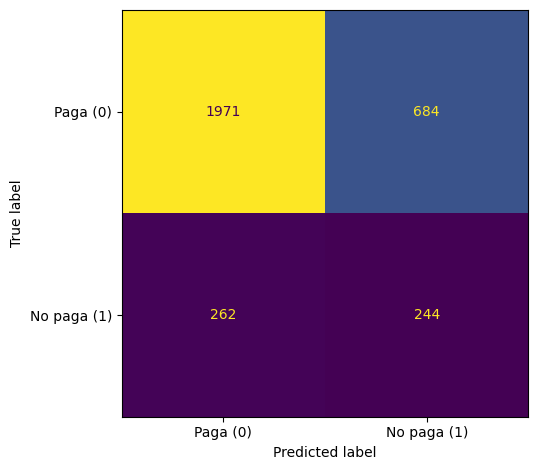

True Negatives (TN): 1971
False Positives (FP): 684
False Negatives (FN): 262
True Positives (TP): 244


In [24]:
# Predictions and classification report
y1_pred = grid.predict(X_test)

print(len(y1_pred))
print(len(y_test))

print(classification_report(y_test, y1_pred))

#Matriz de confusión

ConfusionMatrixDisplay.from_predictions(y_test, y1_pred, display_labels=CLASS_LABELS, colorbar=False)

plt.tight_layout()
plt.show()

conf_matrix_SVM = confusion_matrix(y_test, y1_pred)

# Acceder a los valores de la matriz de confusión
# Clase positiva = 1 (no pagó), convención de sklearn
TN, FP = conf_matrix_SVM[0, 0], conf_matrix_SVM[0, 1]
FN, TP = conf_matrix_SVM[1, 0], conf_matrix_SVM[1, 1]

# Imprimir los valores
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")



### Elección de C y gamma (ítem b)

`GridSearchCV` eligió **`C = 1` y `gamma = 0.001`**, con un F1 promedio de validación de 0,355 para la clase *no pagó*.

- **gamma chico:** con `gamma = 0.001` cada ejemplo influye sobre una región amplia del espacio, por lo que la frontera de decisión es suave, casi lineal. Las combinaciones con `gamma = 1` obtienen F1 de 0,04 a 0,06: con una frontera tan irregular el modelo memoriza el train set y frente a ejemplos nuevos predice casi siempre la clase mayoritaria.
- **C intermedio:** varias combinaciones empatan en el mejor F1 (C entre 0,1 y 10 con gamma 0,001 o 0,01). El resultado es robusto: cualquier modelo de esa zona, con frontera suave y regularización moderada, rinde igual. Esto indica que con estos datos no hay una estructura no lineal compleja que aprovechar.

### Interpretación de la matriz de confusión del SVM (ítem c)

**Convención de clases:** la clase **0** (`not.fully.paid = 0`) corresponde a las personas que **pagaron** el préstamo y la clase **1** a las que **no pagaron**, que es la clase positiva. En la matriz, las filas son la clase real y las columnas la clase predicha.

|  | Predice paga (0) | Predice no paga (1) |
|---|---|---|
| **Paga (0)**: 2655 | 1971 (TN) | 684 (FP) |
| **No paga (1)**: 506 | 262 (FN) | 244 (TP) |

**Interpretación:**

- **Detecta a casi la mitad de los deudores:** identifica 244 de las 506 personas que no pagaron (recall de la clase 1 = 0,48).
- **A costa de rechazar buenos pagadores:** 684 de las 2655 personas que pagaron son clasificadas como *no paga* (recall de la clase 0 = 0,74).
- **La precision de la clase 1 es baja (0,26):** de cada 4 personas que el modelo marca como riesgosas, sólo 1 realmente no paga. Como en el test hay 5 veces más pagadores que deudores, una tasa moderada de errores sobre la clase 0 genera muchos FP.
- **El accuracy (0,70) es menor que el de predecir siempre *paga* (0,84)**, pero el modelo es más útil: el macro avg del recall es 0,61 y el del F1 0,57, es decir, discrimina entre las clases en lugar de ignorar a la minoritaria.
- **Desde el negocio:** el modelo otorgaría 2233 préstamos (los predichos como *paga*), de los cuales 262 no se pagan. La tasa de morosidad de la cartera baja del 16 % al 11,7 %, a cambio de dejar de prestarle a 684 personas que sí hubieran pagado.

**Conclusión:** optimizar el F1 de la clase *no pagó* junto con `class_weight='balanced'` produce un modelo que efectivamente aprende a reconocer deudores. Sin embargo, la separación entre clases es limitada: el modelo cambia aciertos sobre los buenos pagadores por detección de deudores, y la mayoría de los rechazados siguen siendo buenos pagadores.

d) Rebalancear el set de entrenamiento, reservando sólo 1000 ejemplos de la clase mayoritaria. Seleccionar atributos reservando sólo 4 de ellos, usando lo observado en la tarea 2 o bien usando el set [‘credit.policy’, ‘int.rate’, ‘fico’, ‘inq.last.6mths’]. Reentrenar el modelo del ítem anterior usando estos atributos, las clases balanceadas y retuneando los parámetros C y gamma.

## Balanceo de clases.

Las clases estan muy desbalanceadas, hay un 84% de personas que devuelven el prestamo y un 16% que no. Esto puede traer problemas a la hora de entrenar el modelo, por lo que se considera una buena práctica balancear las clases.

Como los nuevos ejemplos que lleguen estarán desbalanceados, quiero mantener X_test tal como está y balancear únicamente el conjunto de entrenamiento X_train. Es importante destacar que no puedo utilizar el DataFrame df_num, ya que podría correr el riesgo de incluir ejemplos destinados al entrenamiento dentro del conjunto de prueba. Por lo tanto, trabajo con X_train, añadiendo la columna de las clases y luego balanceo este nuevo DataFrame. El proceso de balanceo consiste en seleccionar aleatoriamente un número de ejemplos de la clase mayoritaria igual al de la clase minoritaria, que en este caso sería seleccionar 1000 ejemplos de la clase 0 (las personas que sí pagan el préstamo).


Hay que tener en cuenta que cuando usamos StandarScaler() convierte X_train en un arreglo de NumPy asi que tengo que volver a convertirlo en un DataFrame. Y voy a provechar para quedarme con los 4 atributos.

In [25]:
# Convierto a X_train en un DataFrame

X_train_df = pd.DataFrame(X_train, columns=X.columns)


# Convert y_train to DataFrame
y_train_df = pd.DataFrame(y_train).reset_index(drop=True)

# Ensure X_train_df has the same index as y_train_df
X_train_df['not.fully.paid'] = y_train_df.values


# Separar los ejemplos de la clase 0 y 1
df_0 = X_train_df[X_train_df['not.fully.paid'] == 0]  # Clase mayoritaria (personas que pagan el préstamo)
df_1 = X_train_df[X_train_df['not.fully.paid'] == 1]  # Clase minoritaria (personas que no pagan el préstamo)


# Realizar un muestreo aleatorio de la clase mayoritaria para equilibrar las clases
df_0 = df_0.sample(n=1000, random_state=42)  # Seleccionar aleatoriamente 1000

# Combinar los conjuntos de datos balanceados
dfb = pd.concat([df_0, df_1])

# Separar las características (X) y las etiquetas de clase (y) del nuevo conjunto balanceado
X_train_balanced = dfb.drop(columns=['not.fully.paid'])
y_train_balanced = dfb['not.fully.paid']

print(len(X_train_balanced))


2027


### Selección de atributos

Para el SVM del ítem (d) se conservan sólo 4 atributos, los sugeridos por la consigna: **`credit.policy`**, **`int.rate`**, **`fico`** e **`inq.last.6mths`**. El resto de las columnas (`columnstodrop`) se eliminan tanto del train set balanceado como del test set, para que ambos tengan los mismos atributos.

**Justificación desde los datos.** Calculando la correlación de cada atributo con `not.fully.paid` sobre el conjunto de entrenamiento (antes de balancear, sin usar el test), estos 4 atributos son exactamente los de mayor correlación en valor absoluto (ver la celda siguiente):

| Atributo | Correlación con `not.fully.paid` |
|---|---|
| `int.rate` | +0,166 |
| `credit.policy` | −0,161 |
| `inq.last.6mths` | +0,158 |
| `fico` | −0,148 |
| `revol.util` (el siguiente) | +0,091 |

Los atributos descartados tienen correlaciones menores a 0,10. Entre ellos, las variables binarias de `purpose` (salvo `small_business`) y atributos como `days.with.cr.line` o `delinq.2yrs` prácticamente no aportan información sobre la clase.

**Justificación desde el dominio:**

- **`credit.policy`:** indica si el cliente cumple los criterios de crédito de Lending Club. Quienes no los cumplen tienen más probabilidad de no pagar (correlación negativa).
- **`int.rate`:** la tasa de interés que Lending Club asigna según el riesgo que estima para el cliente. Una tasa más alta implica un cliente más riesgoso.
- **`fico`:** el puntaje crediticio. Un puntaje más alto se asocia a mejores pagadores (correlación negativa).
- **`inq.last.6mths`:** cantidad de consultas de crédito en los últimos 6 meses. Muchas consultas sugieren que la persona está buscando financiamiento con urgencia.

**Ventajas de reducir atributos:** el SVM con kernel RBF se basa en distancias, por lo que los atributos irrelevantes agregan ruido y dificultan separar las clases. Con menos dimensiones el modelo es más simple, menos propenso al overfitting y más rápido de tunear.

**Observaciones:**

- `int.rate` y `fico` están bastante correlacionados entre sí (−0,71), porque la tasa se fija en buena parte a partir del puntaje FICO, así que la información que aportan se superpone en parte.
- Incluso los mejores atributos tienen correlaciones bajas (< 0,17) con la clase. Esto anticipa que, con los datos disponibles, va a ser difícil separar a los que pagan de los que no.

In [26]:
# Correlación de cada atributo con la clase, calculada sólo sobre el train set
# (la correlación no cambia con la estandarización, así que se puede usar X_train escalado)
X_train_corr = pd.DataFrame(X_train, columns=X.columns)
corr_clase = X_train_corr.corrwith(y_train.reset_index(drop=True))

tabla_corr = pd.DataFrame({
    'correlación': corr_clase,
    '|correlación|': corr_clase.abs(),
}).sort_values('|correlación|', ascending=False)

print(tabla_corr.round(3))

# Correlación entre los 4 atributos seleccionados
atributos_sel = ['credit.policy', 'int.rate', 'fico', 'inq.last.6mths']
print('\nCorrelación entre los atributos seleccionados:')
print(X_train_corr[atributos_sel].corr().round(2))

                            correlación  |correlación|
int.rate                          0.166          0.166
credit.policy                    -0.161          0.161
inq.last.6mths                    0.158          0.158
fico                             -0.148          0.148
revol.util                        0.091          0.091
purpose_small_business            0.090          0.090
revol.bal                         0.057          0.057
purpose_credit_card              -0.053          0.053
installment                       0.051          0.051
purpose_major_purchase           -0.048          0.048
pub.rec                           0.044          0.044
dti                               0.041          0.041
log.annual.inc                   -0.028          0.028
days.with.cr.line                -0.018          0.018
purpose_debt_consolidation       -0.013          0.013
purpose_educational               0.012          0.012
purpose_home_improvement          0.012          0.012
delinq.2yr

In [27]:
columnstodrop = [
    	'installment',
      'log.annual.inc',
      'dti',
      'days.with.cr.line',
     	'revol.bal',
     	'revol.util',
     	'delinq.2yrs',
     	'pub.rec',
    	'purpose_credit_card',
      'purpose_debt_consolidation',
      'purpose_educational',
     	'purpose_home_improvement',
     	'purpose_major_purchase',
     	'purpose_small_business'
]

# Drop columns from the balanced training set
X1_train = X_train_balanced.drop(columnstodrop, axis=1)



# Drop the same columns from the test set
X1_test = pd.DataFrame(X_test, columns=X.columns).drop(columnstodrop, axis=1)

# Labels remain the same
y1_train = dfb['not.fully.paid']
y1_test = y_test

In [28]:
# Retrain the model with the updated training data
svc = SVC(kernel='rbf', class_weight='balanced')

# Using the same parameter grid for SVM tuning
# scoring='f1': F1 de la clase positiva (1 = no pagó)
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'gamma': [10, 1, 0.1, 0.01, 0.001]}
grid = GridSearchCV(svc, param_grid, scoring='f1', refit=True, verbose=3)
grid.fit(X1_train, y1_train)

# Print best parameters
print("Best Parameters after column removal:", grid.best_params_)



Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ..................C=0.01, gamma=10;, score=0.000 total time=   0.1s
[CV 2/5] END ..................C=0.01, gamma=10;, score=0.000 total time=   0.1s
[CV 3/5] END ..................C=0.01, gamma=10;, score=0.672 total time=   0.1s
[CV 4/5] END ..................C=0.01, gamma=10;, score=0.672 total time=   0.1s
[CV 5/5] END ..................C=0.01, gamma=10;, score=0.672 total time=   0.1s
[CV 1/5] END ...................C=0.01, gamma=1;, score=0.010 total time=   0.1s
[CV 2/5] END ...................C=0.01, gamma=1;, score=0.028 total time=   0.1s
[CV 3/5] END ...................C=0.01, gamma=1;, score=0.670 total time=   0.1s
[CV 4/5] END ...................C=0.01, gamma=1;, score=0.671 total time=   0.1s
[CV 5/5] END ...................C=0.01, gamma=1;, score=0.675 total time=   0.1s
[CV 1/5] END .................C=0.01, gamma=0.1;, score=0.559 total time=   0.1s
[CV 2/5] END .................C=0.01, gamma=0.1

              precision    recall  f1-score   support

           0       0.91      0.31      0.46      2655
           1       0.19      0.84      0.31       506

    accuracy                           0.40      3161
   macro avg       0.55      0.58      0.39      3161
weighted avg       0.80      0.40      0.44      3161



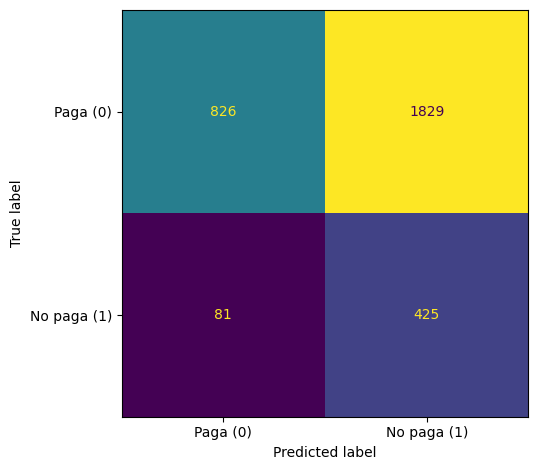

True Negatives (TN): 826
False Positives (FP): 1829
False Negatives (FN): 81
True Positives (TP): 425


In [29]:
# Predictions and classification report
y2_pred = grid.predict(X1_test)

print(classification_report(y1_test, y2_pred))

# Matriz de confusión

ConfusionMatrixDisplay.from_predictions(y1_test, y2_pred, display_labels=CLASS_LABELS, colorbar=False)

plt.tight_layout()

plt.show()

conf_matrix_SVM_balanced = confusion_matrix(y1_test, y2_pred)

# Acceder a los valores de la matriz de confusión
# Clase positiva = 1 (no pagó), convención de sklearn
TN, FP = conf_matrix_SVM_balanced[0, 0], conf_matrix_SVM_balanced[0, 1]
FN, TP = conf_matrix_SVM_balanced[1, 0], conf_matrix_SVM_balanced[1, 1]

# Imprimir los valores
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")


### Interpretación de la matriz de confusión del SVM rebalanceado (ítem e)

El modelo se entrenó con el train set balanceado (1000 ejemplos de la clase 0 y 1027 de la clase 1), sólo con los 4 atributos seleccionados. `GridSearchCV` eligió **`C = 0.1` y `gamma = 10`**, con un F1 de validación de 0,659. Se evalúa sobre el mismo test set desbalanceado que el ítem (c). Igual que en el ítem (c), la clase positiva es la 1 (*no pagó*).

|  | Predice paga (0) | Predice no paga (1) |
|---|---|---|
| **Paga (0)**: 2655 | 826 (TN) | 1829 (FP) |
| **No paga (1)**: 506 | 81 (FN) | 425 (TP) |

**Interpretación:**

- **Detecta a la gran mayoría de los deudores:** identifica 425 de los 506 (recall de la clase 1 = 0,84, contra 0,48 del ítem c).
- **Pero rechaza a la mayoría de los buenos pagadores:** 1829 de las 2655 personas que pagaron son clasificadas como *no paga* (recall de la clase 0 = 0,31, contra 0,74 del ítem c).
- **La precision de la clase 1 cae a 0,19:** de cada 5 personas rechazadas, sólo 1 realmente no paga, apenas por encima del 16 % que se obtendría rechazando al azar.
- **Las métricas globales empeoran respecto del ítem (c):** el accuracy baja de 0,70 a 0,40, el F1 de la clase 1 de 0,34 a 0,31 y el macro avg del F1 de 0,57 a 0,39.
- **Desde el negocio:** el modelo otorgaría sólo 907 préstamos, de los cuales 81 no se pagan (morosidad del 8,9 %). Pero deja sin préstamo a 1829 personas que sí hubieran pagado, un costo de oportunidad muy alto.

**¿Por qué el modelo predice *no paga* tan seguido?** Los hiperparámetros se eligieron maximizando el F1 de la clase 1 en validación cruzada sobre el train set **balanceado**, donde la mitad de los ejemplos son deudores. En esas condiciones, un modelo trivial que predice *no paga* para todos obtiene F1 ≈ 0,67, prácticamente lo mismo que el mejor modelo de la grilla (0,659). El F1 premia entonces a un modelo que se inclina fuertemente hacia la clase 1, y `gamma = 10` está además en el borde de la grilla. Al aplicarlo sobre el test set, donde el 84 % de los solicitantes paga, ese sesgo se traduce en una enorme cantidad de falsos positivos.

**Conclusión:** balancear las clases y reducir los atributos no mejoró el modelo respecto del ítem (c). El F1 de la clase minoritaria es una métrica sensible a la proporción de clases, y calcularlo sobre datos balanceados no refleja la distribución real en la que se usará el modelo. Con una métrica independiente de esa proporción, como `balanced_accuracy` (promedio del recall de ambas clases), la búsqueda elige `C = 1` y `gamma = 1`, con recall de 0,56 para la clase 1 y de 0,66 para la clase 0: un compromiso mucho más razonable.

f) Entrenar una red de perceptrones con una capa oculta con tamaños en el arreglo: [40,60,80,100,120,140,160,180,200,220] usando adam y el train set con las clases balanceadas construído en el ítem (d). Utilizar los valores default para el resto de los parámetros y todos los atributos preparados en el ítem (a).
Graficar best loss vs el tamaño de la capa oculta.


 Tamaño capa oculta  best_loss_
                 40      0.5711
                 60      0.5520
                 80      0.5385
                100      0.5224
                120      0.5197
                140      0.5045
                160      0.4990
                180      0.4844
                200      0.4736
                220      0.4670

No convergieron en max_iter=200 iteraciones: [40, 60, 80, 100, 120, 140, 160, 180, 200, 220]
Tamaño con menor best_loss_: 220


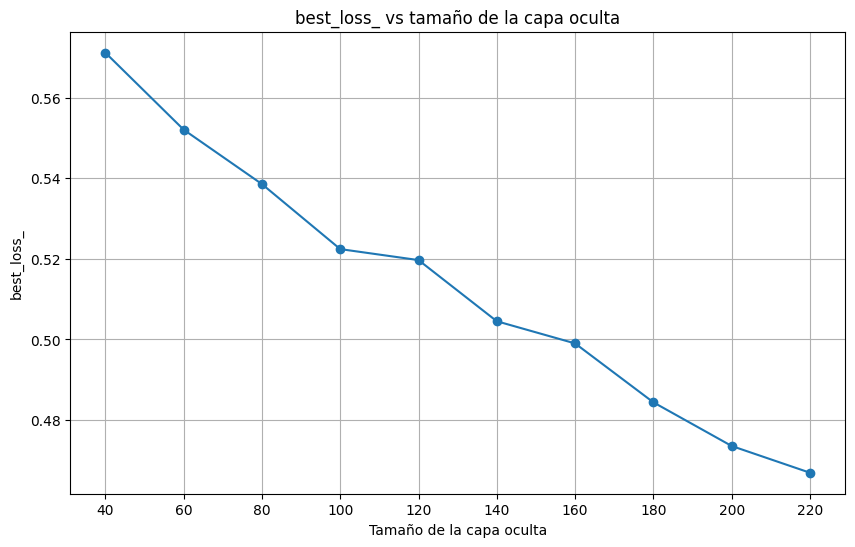

In [30]:
# Tamaños de la capa oculta a evaluar
hidden_layer_sizes = [40, 60, 80, 100, 120, 140, 160, 180, 200, 220]

best_losses = []
sin_converger = []

for size in hidden_layer_sizes:
    # Sólo se fijan el tamaño de la capa y el solver; el resto de los parámetros
    # quedan en sus valores default (max_iter=200, alpha=0.0001, etc.).
    # random_state fija la inicialización de los pesos para que el resultado sea reproducible.
    mlp = MLPClassifier(hidden_layer_sizes=(size,), solver='adam', random_state=42)

    # Se registra si la red no llegó a converger en max_iter iteraciones
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter('always', ConvergenceWarning)
        mlp.fit(X_train_balanced, y_train_balanced)
    if any(issubclass(a.category, ConvergenceWarning) for a in avisos):
        sin_converger.append(size)

    # best_loss_: menor valor de la función de pérdida alcanzado durante el entrenamiento
    best_losses.append(mlp.best_loss_)

tabla_f = pd.DataFrame({'Tamaño capa oculta': hidden_layer_sizes, 'best_loss_': best_losses})
print(tabla_f.round(4).to_string(index=False))
print('\nNo convergieron en max_iter=200 iteraciones:', sin_converger)

# Tamaño con menor best_loss_, que se usa como primera capa en el ítem (g)
best_first_layer_size = hidden_layer_sizes[int(np.argmin(best_losses))]
print('Tamaño con menor best_loss_:', best_first_layer_size)

# Graficar best_loss_ vs el tamaño de la capa oculta
plt.figure(figsize=(10, 6))
plt.plot(hidden_layer_sizes, best_losses, marker='o')
plt.title('best_loss_ vs tamaño de la capa oculta')
plt.xlabel('Tamaño de la capa oculta')
plt.ylabel('best_loss_')
plt.xticks(hidden_layer_sizes)
plt.grid(True)
plt.show()


### Interpretación del ítem (f)

Un **perceptrón multicapa (MLP)** con una capa oculta combina linealmente los atributos en cada neurona de la capa oculta, les aplica una función de activación no lineal (ReLU, por defecto) y a partir de esas salidas calcula la probabilidad de cada clase. Los pesos se ajustan minimizando la **log-loss** (entropía cruzada) más un término de regularización L2 (`alpha`). **Adam** es el optimizador por defecto de `MLPClassifier`: una variante del descenso por gradiente estocástico que adapta la tasa de aprendizaje de cada peso.

`best_loss_` es el **menor valor de la función de pérdida alcanzado sobre el train set** durante el entrenamiento.

**Observaciones:**

- **`best_loss_` disminuye monotónicamente con el tamaño de la capa oculta**, por lo que el mínimo se alcanza con 220 neuronas, el mayor tamaño de la grilla. Una red más grande tiene más parámetros y puede ajustar mejor (o memorizar) los 2027 ejemplos de entrenamiento.
- **Ninguna de las redes converge con los parámetros default:** todas agotan las `max_iter = 200` iteraciones. Es decir, `best_loss_` seguiría bajando si se entrenara por más tiempo.
- **Una menor `best_loss_` no implica un mejor modelo.** Al medirse sobre el train set, este criterio favorece siempre a las redes más grandes y no detecta el sobreajuste. Para elegir el tamaño con un criterio de generalización habría que usar un conjunto de validación (por ejemplo, con `early_stopping=True` o validación cruzada). Siguiendo la consigna, se toma como mejor tamaño el de menor `best_loss_`, que se guarda en `best_first_layer_size` y se usa en el ítem (g).

g) Entrenar una red de perceptrones con dos capas ocultas, la primera con el tamaño que mejor performance obtuvo en el ítem anterior y la segunda con tamaños en el arreglo: [20,30,40,50,60] usando adam y el train set con las clases balanceadas construído en el ítem (d).
Graficar best loss vs el tamaño de la segunda capa oculta.


Primera capa oculta: 220
 Tamaño 2da capa oculta  best_loss_
                     20      0.2054
                     30      0.1655
                     40      0.1456
                     50      0.1310
                     60      0.1065

No convergieron en max_iter=200 iteraciones: [20, 30, 40, 50, 60]
Tamaño con menor best_loss_: 60


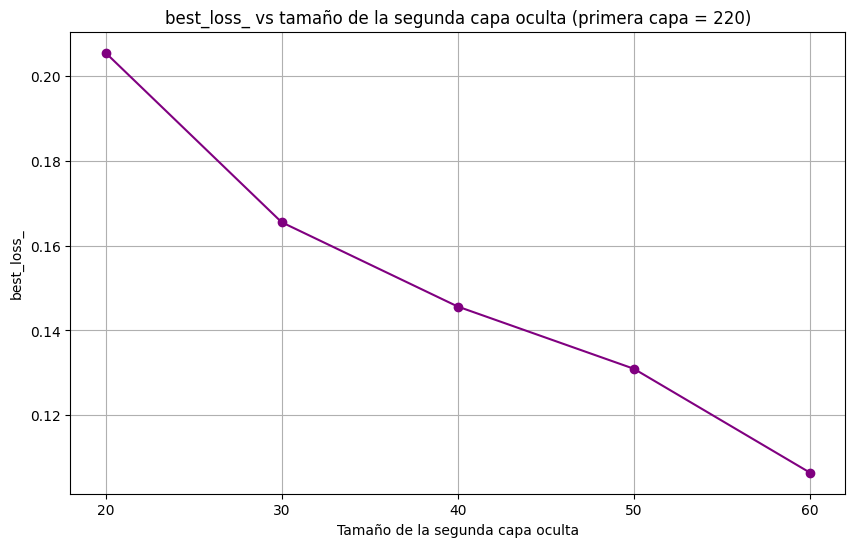

In [31]:
# best_first_layer_size: tamaño de la primera capa oculta obtenido en el ítem (f)
print('Primera capa oculta:', best_first_layer_size)

# Tamaños a evaluar para la segunda capa oculta
second_layer_sizes = [20, 30, 40, 50, 60]

best_losses_second_layer = []
sin_converger_2 = []

for second_size in second_layer_sizes:
    # Primera capa fija, segunda variable; el resto de los parámetros en sus valores default
    mlp = MLPClassifier(hidden_layer_sizes=(best_first_layer_size, second_size),
                        solver='adam', random_state=42)

    # Se registra si la red no llegó a converger en max_iter iteraciones
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter('always', ConvergenceWarning)
        mlp.fit(X_train_balanced, y_train_balanced)
    if any(issubclass(a.category, ConvergenceWarning) for a in avisos):
        sin_converger_2.append(second_size)

    best_losses_second_layer.append(mlp.best_loss_)

tabla_g = pd.DataFrame({'Tamaño 2da capa oculta': second_layer_sizes,
                        'best_loss_': best_losses_second_layer})
print(tabla_g.round(4).to_string(index=False))
print()
print('No convergieron en max_iter=200 iteraciones:', sin_converger_2)

# Tamaño con menor best_loss_, que se usa como segunda capa en el ítem (h)
best_second_layer_size = second_layer_sizes[int(np.argmin(best_losses_second_layer))]
print('Tamaño con menor best_loss_:', best_second_layer_size)

# Graficar best_loss_ vs el tamaño de la segunda capa oculta
plt.figure(figsize=(10, 6))
plt.plot(second_layer_sizes, best_losses_second_layer, marker='o', color='purple')
plt.title(f'best_loss_ vs tamaño de la segunda capa oculta (primera capa = {best_first_layer_size})')
plt.xlabel('Tamaño de la segunda capa oculta')
plt.ylabel('best_loss_')
plt.xticks(second_layer_sizes)
plt.grid(True)
plt.show()


### Interpretación del ítem (g)

Con la primera capa oculta fija en 220 neuronas (el tamaño de menor `best_loss_` del ítem f), se agrega una segunda capa oculta.

**Observaciones:**

- **Nuevamente `best_loss_` disminuye monotónicamente con el tamaño de la capa**, de 0,205 con 20 neuronas a 0,107 con 60, el mayor tamaño de la grilla. Se toma entonces una segunda capa de 60 neuronas, que se guarda en `best_second_layer_size` y se usa en el ítem (h).
- **Agregar una segunda capa reduce fuertemente la pérdida:** la mejor red de una capa alcanzaba `best_loss_` = 0,467, y todas las redes de dos capas quedan por debajo de 0,21. Con unos 17.500 parámetros (18 × 220 + 220 × 60 + 60 × 1 pesos, más los sesgos) y sólo 2027 ejemplos de entrenamiento, la red tiene capacidad de sobra para memorizar el train set.
- **Ninguna de las redes converge** en las 200 iteraciones default, por lo que la pérdida seguiría bajando con más iteraciones.
- **Una pérdida tan baja sobre el train set, en un problema donde los atributos tienen correlaciones bajas con la clase, es un indicio fuerte de sobreajuste.** Era de esperar que el modelo no generalice mejor que la red de una capa, lo que se verifica sobre el test set en el ítem (h).

h) Imprimir la curva best loss , el classification report y la matriz de confusión de la red con dos capas ocultas entrenada con los tamaños observados con mejor performance en los ítems (f) y (g) y el train set con las clases balanceadas construído en el ítem (d).

Capas ocultas: (220, 60)
best_loss_: 0.1065
Iteraciones: 200 | Convergió: False


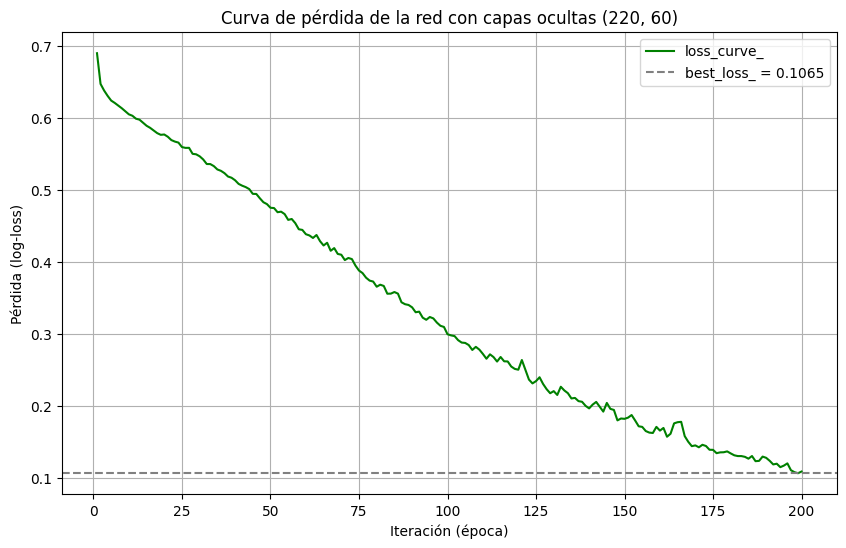

              precision    recall  f1-score   support

           0       0.87      0.58      0.69      2655
           1       0.19      0.53      0.28       506

    accuracy                           0.57      3161
   macro avg       0.53      0.55      0.49      3161
weighted avg       0.76      0.57      0.63      3161



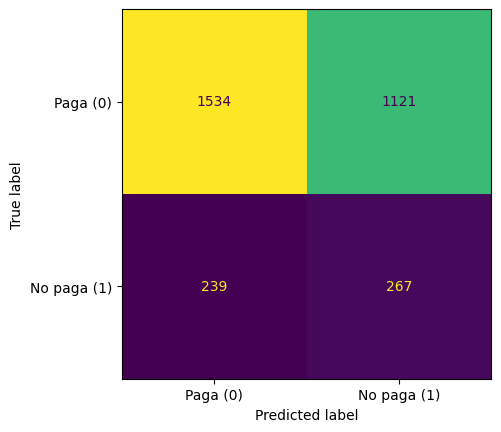

True Negatives (TN): 1534
False Positives (FP): 1121
False Negatives (FN): 239
True Positives (TP): 267


In [32]:
# Red con dos capas ocultas, con los tamaños de menor best_loss_ de los ítems (f) y (g)
print('Capas ocultas:', (best_first_layer_size, best_second_layer_size))

mlp = MLPClassifier(hidden_layer_sizes=(best_first_layer_size, best_second_layer_size),
                    solver='adam', random_state=42)

with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter('always', ConvergenceWarning)
    mlp.fit(X_train_balanced, y_train_balanced)
convergio = not any(issubclass(a.category, ConvergenceWarning) for a in avisos)

print('best_loss_:', round(mlp.best_loss_, 4))
print('Iteraciones:', mlp.n_iter_, '| Convergió:', convergio)

# Curva de pérdida durante el entrenamiento (loss_curve_), marcando best_loss_
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_, color='green', label='loss_curve_')
plt.axhline(mlp.best_loss_, color='gray', linestyle='--', label=f'best_loss_ = {mlp.best_loss_:.4f}')
plt.title(f'Curva de pérdida de la red con capas ocultas {(best_first_layer_size, best_second_layer_size)}')
plt.xlabel('Iteración (época)')
plt.ylabel('Pérdida (log-loss)')
plt.legend()
plt.grid(True)
plt.show()

# Predicciones sobre el test set (como DataFrame, con los mismos nombres de columnas que el train)
X_test_df = pd.DataFrame(X_test, columns=X.columns)
y3_pred = mlp.predict(X_test_df)

print(classification_report(y_test, y3_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, y3_pred,
    display_labels=CLASS_LABELS, colorbar=False
)
plt.show()

conf_matrix_MLP = confusion_matrix(y_test, y3_pred)

# Acceder a los valores de la matriz de confusión
# Clase positiva = 1 (no pagó), convención de sklearn
TN, FP = conf_matrix_MLP[0, 0], conf_matrix_MLP[0, 1]
FN, TP = conf_matrix_MLP[1, 0], conf_matrix_MLP[1, 1]

# Imprimir los valores
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")


### Interpretación del ítem (h)

La red final tiene dos capas ocultas de **220 y 60 neuronas** (los tamaños de menor `best_loss_` en los ítems f y g) y se entrenó con el train set balanceado y todos los atributos.

**Curva de pérdida:** la log-loss baja de forma sostenida durante las 200 iteraciones y termina en `best_loss_` = 0,107, sin llegar a converger. La red sigue ajustándose cada vez más al train set.

|  | Predice paga (0) | Predice no paga (1) |
|---|---|---|
| **Paga (0)**: 2655 | 1534 (TN) | 1121 (FP) |
| **No paga (1)**: 506 | 239 (FN) | 267 (TP) |

**Interpretación:**

- **Detecta a la mitad de los deudores:** 267 de 506 (recall de la clase 1 = 0,53).
- **Pero rechaza al 42 % de los buenos pagadores:** 1121 de 2655 (recall de la clase 0 = 0,58).
- **La precision de la clase 1 es de 0,19:** de cada 5 personas rechazadas, sólo 1 realmente no paga.
- **Desde el negocio:** otorgaría 1773 préstamos, de los cuales 239 no se pagan (morosidad del 13,5 %), y deja sin préstamo a 1121 buenos pagadores.

**Sobreajuste:** sobre el mismo train set balanceado con el que se entrenó, la red alcanza un accuracy de 0,98. Sobre el test set, su balanced accuracy (promedio del recall de ambas clases) es de sólo 0,55, apenas por encima del 0,50 de un clasificador al azar. La red memorizó los ejemplos de entrenamiento en lugar de aprender patrones que generalicen.

**Comparación con el SVM del ítem (c):** la MLP detecta algunos deudores más (recall 0,53 contra 0,48), pero rechaza muchos más buenos pagadores (1121 contra 684). Su F1 macro (0,49 contra 0,57) y su precision sobre la clase 1 (0,19 contra 0,26) son peores.

**Conclusión:** elegir la arquitectura por `best_loss_` lleva a la red más grande de cada grilla, porque esa medida se calcula sobre el train set y sólo indica qué tan bien se ajusta la red a esos datos. Con 2027 ejemplos y atributos poco informativos, una red de unos 17.500 parámetros sobreajusta. Para mejorarla habría que elegir la arquitectura con un conjunto de validación (`early_stopping=True` o validación cruzada), aumentar la regularización (`alpha`) o usar redes más chicas. La celda siguiente lo muestra comparando el desempeño de cada arquitectura sobre el train y el test set.

In [ ]:
# Diagnóstico de sobreajuste: desempeño de cada arquitectura de los ítems (f) y (g)
# sobre el train set balanceado y sobre el test set.
# El test set se usa sólo para ilustrar el sobreajuste, no para elegir la arquitectura.
arquitecturas = [(s,) for s in hidden_layer_sizes] + [(best_first_layer_size, s) for s in second_layer_sizes]

filas_arq = []
for arq in arquitecturas:
    red = MLPClassifier(hidden_layer_sizes=arq, solver='adam', random_state=42)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        red.fit(X_train_balanced, y_train_balanced)
    filas_arq.append({
        'Capas ocultas': str(arq),
        'best_loss_': red.best_loss_,
        'Balanced acc. train': balanced_accuracy_score(y_train_balanced, red.predict(X_train_balanced)),
        'Balanced acc. test': balanced_accuracy_score(y_test, red.predict(X_test_df)),
    })

tabla_arq = pd.DataFrame(filas_arq).set_index('Capas ocultas')
print(tabla_arq.round(3))

plt.figure(figsize=(12, 5))
plt.plot(tabla_arq.index, tabla_arq['Balanced acc. train'], marker='o', label='Train (balanceado)')
plt.plot(tabla_arq.index, tabla_arq['Balanced acc. test'], marker='o', label='Test')
plt.axhline(0.5, color='gray', linestyle='--', label='Clasificador al azar')
plt.title('Balanced accuracy en train y test según la arquitectura')
plt.xlabel('Capas ocultas')
plt.ylabel('Balanced accuracy')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Resultado:** a medida que crece la red, `best_loss_` baja y el balanced accuracy sobre el train sube (de 0,70 con 40 neuronas a 0,98 con la red de 220 y 60). Sobre el test, en cambio, el desempeño no mejora: el máximo lo alcanza la red de una capa con 60 neuronas (0,60) y las redes de dos capas quedan alrededor de 0,55. La brecha creciente entre train y test es la firma del sobreajuste: la capacidad adicional de la red se usa para memorizar el train set, no para encontrar patrones que generalicen.

i) Se denomina Return on Investment (ROI) *per loan* al cociente:

$$\text{ROI} = \frac{\text{Total Benefits} - \text{Total Costs}}{\text{Loans granted}}$$

con $\text{Total Benefits} = TP \times B$, $\text{Total Costs} = FP \times C_{FP} + FN \times C_{FN}$ y $\text{Loans granted} = TP + FP$. Para Joe Loan, $B = 0{,}3$, $C_{FP} = 0{,}8$ y $C_{FN} = 0{,}3$.

Construir una tabla con los valores de TP, FP, FN y retorno por préstamo de los modelos: random, majority, SVM del ítem (c), SVM del ítem (e), MLP del ítem (h) y Naive Bayes entrenado con los atributos y clases balanceadas del ítem (d).

### Convención de clases para el ROI

En todo el notebook la clase positiva es la **1 (no pagó)**, que es la convención de sklearn. La consigna, en cambio, define el ROI tomando como positivo a quien **pagó** (clase 0), ya que el préstamo se otorga cuando el modelo predice que la persona va a pagar. Para calcular el ROI se traducen las entradas de la matriz de confusión:

| Consigna (positivo = pagó) | Significado | Notebook (positivo = no pagó) |
|---|---|---|
| $TP$ | se predijo *paga* y pagó | TN |
| $FP$ | se predijo *paga* y no pagó | FN |
| $FN$ | se predijo *no paga* pero pagó | FP |
| $TN$ | se predijo *no paga* y no pagó | TP |

En la tabla final, las columnas TP, FP y FN están expresadas en la convención de la consigna.

              precision    recall  f1-score   support

           0       0.83      0.49      0.62      2655
           1       0.15      0.48      0.23       506

    accuracy                           0.49      3161
   macro avg       0.49      0.48      0.42      3161
weighted avg       0.72      0.49      0.56      3161



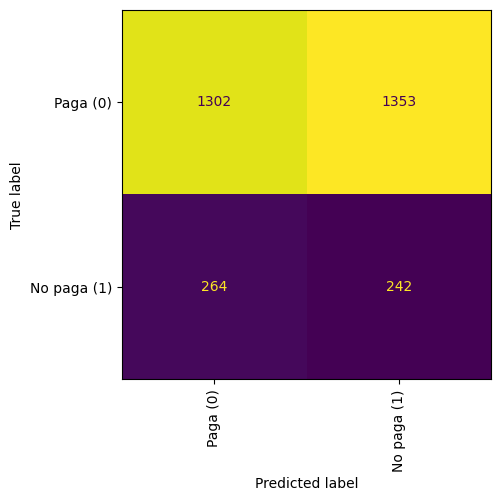

True Negatives (TN): 1302
False Positives (FP): 1353
False Negatives (FN): 264
True Positives (TP): 242


In [33]:
# random choice

np.random.seed(42)  # Asegurar la reproducibilidad
n_samples = len(X_test)

# Predecir 0 o 1 al azar con igual probabilidad (p=0.5 para cada clase)
y_pred_random = np.random.choice([0, 1], size=n_samples, p=[0.5, 0.5])


print(classification_report(y_test, y_pred_random))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_random,
    display_labels=CLASS_LABELS, colorbar=False,
    xticks_rotation='vertical'
)


plt.show()

conf_matrix_random = confusion_matrix(y_test, y_pred_random)

# Acceder a los valores de la matriz de confusión
# Clase positiva = 1 (no pagó), convención de sklearn
TN, FP = conf_matrix_random[0, 0], conf_matrix_random[0, 1]
FN, TP = conf_matrix_random[1, 0], conf_matrix_random[1, 1]

# Imprimir los valores
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")



              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2655
           1       0.00      0.00      0.00       506

    accuracy                           0.84      3161
   macro avg       0.42      0.50      0.46      3161
weighted avg       0.71      0.84      0.77      3161



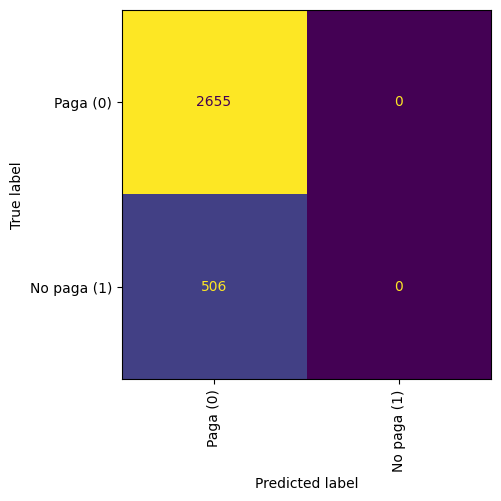

True Negatives (TN): 2655
False Positives (FP): 0
False Negatives (FN): 506
True Positives (TP): 0


In [34]:
# Modelo majority: se otorga el préstamo a la totalidad de los solicitantes,
# es decir, se predice siempre la clase 0 (paga), que es la mayoritaria.
# Se entrena con el train set original (desbalanceado): en el balanceado la clase
# mayoritaria pasa a ser la 1 y el modelo no le prestaría a nadie.
majority_clf = DummyClassifier(strategy='most_frequent')
majority_clf.fit(X_train, y_train)

# Hacer predicciones con el modelo de clase mayoritaria
y_pred_majority = majority_clf.predict(X_test)

# Evaluación (zero_division=0 porque nunca se predice la clase 1)
print(classification_report(y_test, y_pred_majority, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_majority,
    display_labels=CLASS_LABELS, colorbar=False,
    xticks_rotation='vertical'
)


plt.show()

conf_matrix_majority = confusion_matrix(y_test, y_pred_majority)

# Acceder a los valores de la matriz de confusión
# Clase positiva = 1 (no pagó), convención de sklearn
TN, FP = conf_matrix_majority[0, 0], conf_matrix_majority[0, 1]
FN, TP = conf_matrix_majority[1, 0], conf_matrix_majority[1, 1]

# Imprimir los valores
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")


              precision    recall  f1-score   support

           0       0.88      0.74      0.80      2655
           1       0.25      0.46      0.33       506

    accuracy                           0.70      3161
   macro avg       0.57      0.60      0.56      3161
weighted avg       0.78      0.70      0.73      3161



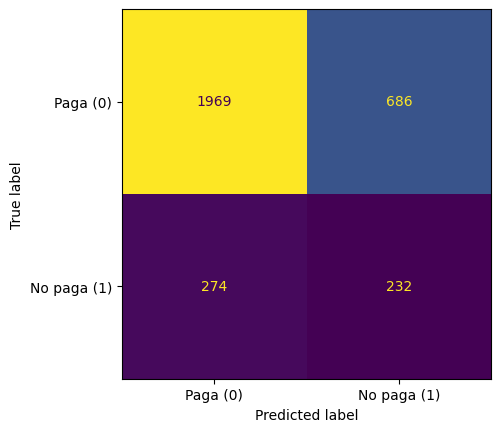

True Negatives (TN): 1969
False Positives (FP): 686
False Negatives (FN): 274
True Positives (TP): 232


In [35]:
# Naive Bayes con los 4 atributos y las clases balanceadas del ítem (d)
nb_clf = GaussianNB()
nb_clf.fit(X1_train, y1_train)

y4_pred = nb_clf.predict(X1_test)

print(classification_report(y1_test, y4_pred))

ConfusionMatrixDisplay.from_predictions(
    y1_test, y4_pred,
    display_labels=CLASS_LABELS, colorbar=False
)

plt.show()

conf_matrix_NB = confusion_matrix(y1_test, y4_pred)

# Acceder a los valores de la matriz de confusión
# Clase positiva = 1 (no pagó), convención de sklearn
TN, FP = conf_matrix_NB[0, 0], conf_matrix_NB[0, 1]
FN, TP = conf_matrix_NB[1, 0], conf_matrix_NB[1, 1]

# Imprimir los valores
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")


In [36]:
# Parámetros del negocio de Joe Loan
B = 0.3      # beneficio por préstamo pagado
C_FP = 0.8   # costo de prestarle a quien no paga
C_FN = 0.3   # costo de oportunidad de no prestarle a quien sí paga

modelos = {
    'Random (p = 1/2)': y_pred_random,
    'Majority (presta a todos)': y_pred_majority,
    'SVM (c)': y1_pred,
    'SVM balanceado, 4 atributos (e)': y2_pred,
    'MLP (h)': y3_pred,
    'Naive Bayes, 4 atributos': y4_pred,
}

filas = []
for nombre, y_pred in modelos.items():
    # Matriz con la convención del notebook (clase positiva = 1, no pagó)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    # Traducción a la convención de la consigna (positivo = pagó)
    TP_roi = tn  # se predijo que paga y pagó
    FP_roi = fn  # se predijo que paga y no pagó
    FN_roi = fp  # se predijo que no paga pero pagó

    prestamos = TP_roi + FP_roi
    beneficio_total = TP_roi * B
    costo_total = FP_roi * C_FP + FN_roi * C_FN
    roi = (beneficio_total - costo_total) / prestamos if prestamos > 0 else np.nan

    filas.append({
        'Modelo': nombre,
        'TP': TP_roi,
        'FP': FP_roi,
        'FN': FN_roi,
        'Préstamos otorgados': prestamos,
        'ROI por préstamo': roi,
    })

tabla_roi = pd.DataFrame(filas).set_index('Modelo')
tabla_roi.round({'ROI por préstamo': 4})


,TP,FP,FN,Préstamos otorgados,ROI por préstamo
Modelo,,,,,
Random (p = 1/2),1302,264,1353,1566,-0.1446
Majority (presta a todos),2655,506,0,3161,0.1239
SVM (c),1971,262,684,2233,0.0790
"SVM balanceado, 4 atributos (e)",826,81,1829,907,-0.4032
MLP (h),1534,239,1121,1773,-0.0380
"Naive Bayes, 4 atributos",1969,274,686,2243,0.0739


j) Discutir desde la perspectiva del dominio la tabla del ítem anterior. ¿Es viable el negocio de Joe? ¿Por qué? ¿Qué aportan los clasificadores entrenados al problema? ¿Cuál puede ser el origen del problema al que nos enfrentamos con este desafío de clasificación?

Para la discusión se agregan a la tabla del ítem (i) dos indicadores más: la **morosidad de la cartera** (proporción de préstamos otorgados que no se pagan) y la **ganancia neta**, es decir, el dinero que efectivamente gana Joe, sin el costo de oportunidad $C_{FN}$, que no es una pérdida de dinero sino una ganancia que se deja de obtener.

In [ ]:
# Indicadores adicionales para la discusión, a partir de la tabla del ítem (i)
tabla_j = tabla_roi.copy()
tabla_j['Morosidad de la cartera'] = tabla_j['FP'] / tabla_j['Préstamos otorgados']
tabla_j['Ganancia neta'] = tabla_j['TP'] * B - tabla_j['FP'] * C_FP
tabla_j['Ganancia neta por préstamo'] = tabla_j['Ganancia neta'] / tabla_j['Préstamos otorgados']

tabla_j.round(3)


### Discusión

**¿Es viable el negocio de Joe?** Sí. La estrategia más simple, prestarle a todos los solicitantes (*majority*), tiene un ROI de **0,124 por préstamo**: por cada peso prestado, Joe gana en promedio 12 centavos. Si $p$ es la proporción de deudores, prestar a todos da un ROI de $0{,}3\,(1-p) - 0{,}8\,p = 0{,}3 - 1{,}1\,p$, que es positivo mientras la morosidad sea menor al 27 %. En el dataset es del 16 %, así que el negocio tiene un margen razonable. Que el modelo *random* pierda dinero (−0,145) muestra que no cualquier estrategia funciona: rechazar a ciegas genera un alto costo de oportunidad sin reducir la morosidad.

**¿Qué aportan los clasificadores?** Según el ROI de la consigna, **ninguno supera a prestarle a todos**. Sin embargo, sí aportan información:

- **Reducen la morosidad de la cartera:** del 16 % sin modelo al 11,7 % con el SVM del ítem (c), al 12,2 % con Naive Bayes y al 8,9 % con el SVM del ítem (e). Es decir, los clientes que el modelo aprueba son efectivamente menos riesgosos.
- **Aumentan la ganancia neta por peso prestado:** de 0,124 a 0,171 con el SVM (c) y a 0,166 con Naive Bayes. Si Joe tiene un capital limitado y no puede prestarle a todos, el clasificador le indica a quién priorizar.
- **Pero no aumentan la ganancia total:** el SVM (c) gana prácticamente lo mismo que prestarle a todos (382 contra 392 en el test set) prestando un 30 % menos de dinero. El dinero que se ahorra en deudores se pierde en buenos pagadores rechazados.

**¿Por qué los clasificadores no superan a la estrategia trivial?** Hay dos causas que se combinan:

1. **El umbral de decisión no refleja los costos del negocio.** Según la fórmula del ROI, prestarle a quien no paga cuesta 0,8, mientras que rechazar a un buen pagador cuesta 0,6 (se pierde la ganancia de 0,3 y se suma el costo de oportunidad de 0,3). Si $q$ es la probabilidad de que un cliente no pague, conviene prestarle cuando $0{,}6\,(1-q) > 0{,}8\,q$, es decir, cuando **$q < 0{,}43$**. Pero al balancear las clases (o usar `class_weight='balanced'`), los modelos aprenden como si la mitad de los clientes fueran deudores, y terminan rechazando a cualquiera cuyo riesgo esté por encima del promedio (≈ 16 %). Rechazan a demasiada gente. Un mejor uso de estos modelos sería estimar la probabilidad de no pago y prestar sólo cuando sea menor a 0,43. Con atributos tan poco informativos, muy pocos clientes superan ese umbral, por lo que la decisión óptima se parece mucho a prestarle a casi todos.
2. **Los atributos tienen poco poder predictivo.** Ninguno tiene una correlación mayor a 0,17 con la clase, y los mejores modelos apenas alcanzan un balanced accuracy de 0,60 sobre el test set. Con tan poca señal, cualquier intento de detectar deudores produce muchos falsos positivos.

**¿Cuál puede ser el origen del problema?** El problema de fondo está en los datos:

- **Sesgo de selección:** el dataset sólo contiene préstamos que Lending Club **ya aprobó**. Los solicitantes más riesgosos fueron filtrados antes de llegar a los datos, por lo que los que quedan son relativamente homogéneos y difíciles de distinguir entre sí.
- **El riesgo ya está incorporado en los atributos:** la tasa de interés (`int.rate`) se fija a partir del FICO y de la evaluación de riesgo de Lending Club. El modelo intenta reaprender una evaluación que ya se hizo, y la información que queda sin explotar es poca.
- **Causas de impago no observables:** gran parte de los impagos se deben a eventos posteriores al otorgamiento del préstamo (pérdida del empleo, problemas de salud, gastos imprevistos) que ningún atributo de la solicitud puede anticipar.
- **Desbalance de clases:** sólo el 16 % de los préstamos no se paga, lo que dificulta aprender a reconocer a los deudores y hace engañosas métricas como el accuracy.

**Conclusión:** el negocio de Joe es viable incluso sin ningún modelo. Los clasificadores entrenados mejoran la calidad de la cartera y el retorno por peso prestado, pero con los datos disponibles no aumentan la ganancia total, y entrenados con clases balanceadas son demasiado restrictivos. Para que un modelo agregue valor real haría falta incorporar los costos del negocio en la decisión (ajustando el umbral de probabilidad) y, sobre todo, contar con atributos que aporten información que Lending Club no haya usado ya para aprobar y fijar la tasa de cada préstamo.